# Stage 3 — Baseline supervised models

Three models in increasing order of sophistication, so each one's contribution
is visible, and every result is defensible without hand-waving:

1. **Logistic regression** — linear, fully interpretable reference
2. **Random forest** — captures the non-monotonic structure Stage 2 found
3. **XGBoost** — gradient boosting, usually strongest on tabular data this size

No deep learning. With 10,000 rows and 339 positives, a neural network would be
both harder to justify and harder to explain in a review.

## Protocol

- Stratified **80/20 split**, and the test set is not touched until Stage 6
- **5-fold stratified cross-validation** inside the training set for selection
- The entire pipeline — impute, scale, one-hot — is **refitted inside every
  fold**, so no validation-fold statistic leaks into its own training fold
- Imbalance handled by **class weights**, never synthetic oversampling
- The decision threshold is tuned on **out-of-fold predictions only**


In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as cfg, data, features, eda, models, evaluate, anomaly, explain, viz
viz.apply_style()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)


In [2]:
df = features.add_physics_features(data.add_targets(data.load_raw()))
train_df, test_df = data.stratified_split(df)
data.describe_split(train_df, test_df)

,split,rows,failures,failure_rate_%,TWF,HDF,PWF,OSF
0,train,8000,271,3.388,36,93,75,78
1,test,2000,68,3.400,10,22,20,20


The split is stratified on the joint failure/mode signature, not just the
binary label — with only 46 tool-wear failures in total, a naive split can leave
a mode badly under-represented on one side.


In [3]:
X_train = features.X_frame(train_df); y_train = train_df["y_failure"].to_numpy()
X_test  = features.X_frame(test_df);  y_test  = test_df["y_failure"].to_numpy()

pos_weight = models.positive_weight(y_train)
print(f"training rows      : {len(X_train):,}")
print(f"training failures  : {int(y_train.sum())} ({y_train.mean():.2%})")
print(f"negative/positive  : {pos_weight:.1f}  -> used as scale_pos_weight")
print(f"features           : {len(cfg.FEATURE_COLS)} ({len(cfg.NUMERIC_FEATURES)} numeric + machine type)")

training rows      : 8,000
training failures  : 271 (3.39%)
negative/positive  : 28.5  -> used as scale_pos_weight
features           : 11 (10 numeric + machine type)


## Cross-validation

`cross_val_oof` returns out-of-fold probabilities for every row of the training
set. Those serve two purposes: an honest generalisation estimate for model
selection, and a clean sample for threshold tuning that never touches the test
set.


In [4]:
zoo = models.build_models(pos_weight=pos_weight)
oof, fold_scores = models.cross_val_oof(zoo, X_train, y_train)
cv_table = models.cv_summary(fold_scores)
cv_table

,model,cv_pr_auc_mean,cv_pr_auc_std,folds
1,Random forest,0.881178,0.025060,"[0.8539, 0.868, 0.9196, 0.8629, 0.9014]"
2,XGBoost,0.863620,0.030990,"[0.8294, 0.8852, 0.8948, 0.8226, 0.886]"
0,Logistic regression,0.472933,0.055508,"[0.4686, 0.5149, 0.5522, 0.4306, 0.3984]"


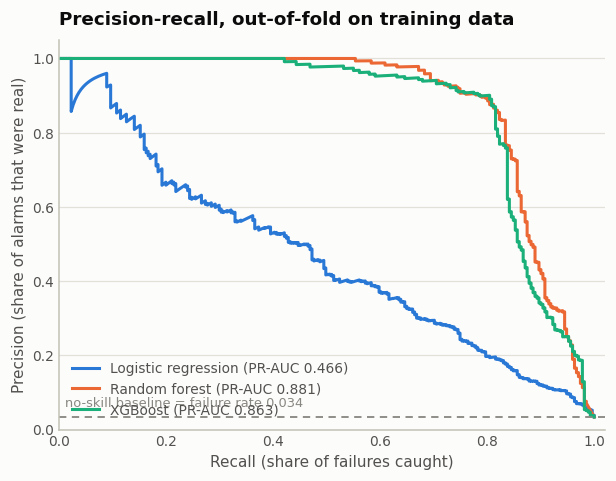

In [5]:
ax = evaluate.plot_pr_curves(oof, y_train,
        title="Precision-recall, out-of-fold on training data")
plt.show()

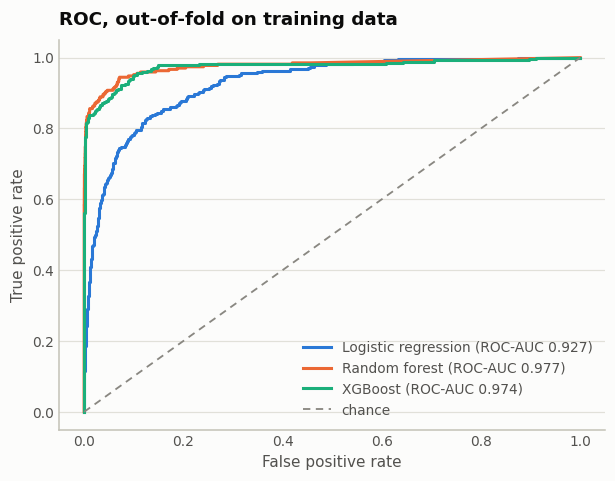

In [6]:
ax = evaluate.plot_roc_curves(oof, y_train,
        title="ROC, out-of-fold on training data")
plt.show()

The gap between the two tree ensembles and logistic regression is large — and
it is exactly the gap Stage 2's operating-envelope figure predicted. Failures
sit in two opposite corners of the speed/torque plane, and no single linear
boundary separates two opposite corners from the middle. The forest can.

Note also how differently the two curve families read. The ROC curves look
respectable for all three models, including the linear one. The PR curves do
not. With 3.4% positives, ROC-AUC is flattered by the enormous negative class;
PR-AUC is not. This is why PR-AUC is the headline.


In [7]:
best_name = cv_table.iloc[0]["model"]
oof_best = oof[best_name]
print(f"selected on cross-validated PR-AUC: {best_name}")
print(f"  mean {cv_table.iloc[0]['cv_pr_auc_mean']:.4f}  "
      f"std {cv_table.iloc[0]['cv_pr_auc_std']:.4f}")
print(f"  folds {cv_table.iloc[0]['folds']}")

selected on cross-validated PR-AUC: Random forest
  mean 0.8812  std 0.0251
  folds [0.8539, 0.868, 0.9196, 0.8629, 0.9014]


## Choosing the operating point

A classifier outputs a probability; maintenance needs a yes/no. The threshold
that converts one to the other is a **business decision**, not a statistical
one, and 0.5 is almost never the right answer for a rare event.

The assumption used here: **a missed failure costs 10× an unnecessary
inspection.** An unplanned stoppage means lost production, possible collateral
damage and emergency labour; an unnecessary inspection means an hour of a
technician's time. Both true positives and false positives incur that same
inspection cost, so it cancels and the objective reduces to

$$\text{cost} = 10 \times \text{missed failures} + 1 \times \text{false alarms}$$


cost-optimal threshold: 0.2510
out-of-fold cost      : 478 inspection-units


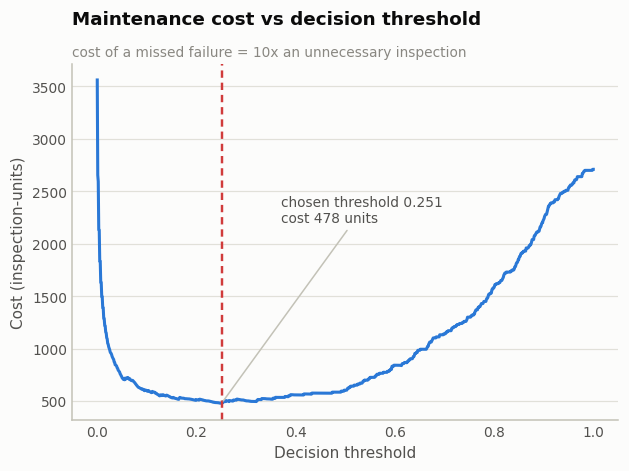

In [8]:
tuned = evaluate.tune_threshold_by_cost(y_train, oof_best)
threshold = tuned["threshold"]
print(f"cost-optimal threshold: {threshold:.4f}")
print(f"out-of-fold cost      : {tuned['cost_units']:.0f} inspection-units")
ax = evaluate.plot_threshold_cost(tuned)
plt.show()

The curve is steep on the left and shallow on the right of the minimum, which
is itself informative: being slightly too aggressive costs far less than being
slightly too conservative. That asymmetry is the whole argument for tuning the
threshold rather than accepting 0.5.

### Sensitivity to the cost assumption

The 10:1 ratio was chosen, not measured. So here is what happens across a
plausible range — this table is the defensible part.


In [9]:
sweep = evaluate.threshold_cost_sweep(y_train, oof_best)
sweep

,cost_ratio_FN_to_FP,threshold,precision,recall,f2,false_alarms,missed_failures,cost_units,cost_saved_pct
0,5:1,0.321,0.8339,0.8339,0.8339,45,45,270.0,80.1
1,10:1,0.251,0.7250,0.8561,0.8262,88,39,478.0,82.4
2,20:1,0.126,0.4908,0.8893,0.7651,250,30,850.0,84.3
3,50:1,0.054,0.3157,0.9446,0.6755,555,15,1305.0,90.4


Reading it: as a breakdown gets more expensive relative to an inspection, the
threshold drops and recall rises — at 50:1 the system catches 94% of failures,
but raises 555 false alarms to do it. A maintenance manager picks the row, not
the data scientist. What the model provides is the trade-off curve.


In [10]:
rap = evaluate.recall_at_precision(y_train, oof_best, 0.90)
print(f"out-of-fold recall at >=90% precision: {rap['recall']:.3f} "
      f"(threshold {rap['threshold']:.3f})")
print("i.e. accepting at most one false alarm in ten, the system still catches")
print(f"{rap['recall']:.1%} of failures.")

out-of-fold recall at >=90% precision: 0.786 (threshold 0.504)
i.e. accepting at most one false alarm in ten, the system still catches
78.6% of failures.


## Fit the selected model on all training data


In [11]:
best_model = zoo[best_name]
if best_name == "XGBoost":
    best_model.set_params(clf__scale_pos_weight=pos_weight)
best_model.fit(X_train, y_train)
print(f"{best_name} fitted on {len(X_train):,} rows")
print(f"decision threshold held at {threshold:.4f} (chosen out-of-fold)")

Random forest fitted on 8,000 rows
decision threshold held at 0.2510 (chosen out-of-fold)


## What Stage 3 established

- The tree ensembles clearly beat the linear baseline, for the structural reason
  Stage 2 identified — not by accident
- PR-AUC and ROC-AUC tell different stories, and for a 3.4% positive rate the
  PR view is the honest one
- The operating point comes from maintenance economics, and its sensitivity to
  that assumption is quantified rather than hidden
- The test set is still sealed

Next: Stage 4 adds an unsupervised detector for faults the classifier has never
been shown.
